<a href="https://colab.research.google.com/github/nomadcodin/XAI_HybridNet/blob/main/XAI_HybridNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision torchaudio timm kaggle matplotlib seaborn scikit-learn

!pip install lime scikit-image

!pip install shap



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 19.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d19830669f24c504286bd69a452191cee55ed2d6287f18f8bfa0b2eae6a56fe1
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/chest_xray')


['.DS_Store', 'train', 'test', 'val']

Dataset Pipeline

In [ ]:
import torch
import numpy as np
import cv2
from torchvision import transforms
from PIL import Image   # <-- REQUIRED FIX

class MildPreprocess:
    def __call__(self, img):
        # Convert PIL → NumPy
        img = np.array(img)

        # 1. Histogram equalization on Y channel
        img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
        img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
        img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

        # 2. Tiny Gaussian noise
        noise = np.random.normal(0, 3, img.shape).astype(np.int16)
        img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

        # 3. Random 5% crop
        h, w = img.shape[:2]
        ch, cw = int(h*0.05), int(w*0.05)
        y1 = np.random.randint(0, ch+1)
        x1 = np.random.randint(0, cw+1)
        y2 = h - np.random.randint(0, ch+1)
        x2 = w - np.random.randint(0, cw+1)
        img = img[y1:y2, x1:x2]
        img = cv2.resize(img, (224, 224))

        # Back → PIL image
        return Image.fromarray(img)


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = '/content/drive/MyDrive/chest_xray'

transform = transforms.Compose([
    MildPreprocess(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform)
val_ds   = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform)
test_ds  = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=32)
test_dl  = DataLoader(test_ds, batch_size=32)


Sample Visualisation


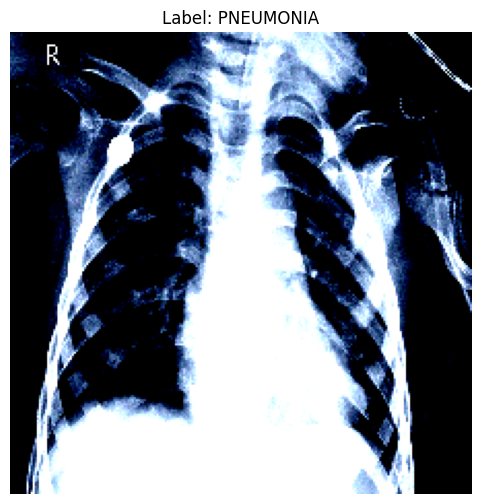

In [ ]:
import matplotlib.pyplot as plt
images, labels = next(iter(train_dl))
plt.figure(figsize=(6,6))
plt.imshow(images[0].permute(1,2,0))
plt.title(f"Label: {train_ds.classes[labels[0]]}")
plt.axis('off')
plt.show()


##ResNet-50 Baseline Model

Import and Setup

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.optim as optim
import time, copy, os

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


Dataset Paths and Loaders

In [ ]:
data_dir = '/content/drive/MyDrive/chest_xray'

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform)
val_ds   = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform)
test_ds  = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_dl   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

dataloaders = {'train': train_dl, 'val': val_dl}
dataset_sizes = {'train': len(train_ds), 'val': len(val_ds)}
class_names = train_ds.classes
print("Classes:", class_names)


Classes: ['NORMAL', 'PNEUMONIA']


Load Pretrained ResNet-50 and Modify for 2 Classes

In [ ]:
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Replace the final FC layer
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, 2)

resnet = resnet.to(device)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 149MB/s]


Define Loss and Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)


Training Function

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # deep copy model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model


Train the Model

In [ ]:
resnet = train_model(resnet, criterion, optimizer, scheduler, num_epochs=10)


Epoch 1/10
----------
train Loss: 0.0895 Acc: 0.9624
val Loss: 0.1024 Acc: 0.9375

Epoch 2/10
----------
train Loss: 0.0258 Acc: 0.9902
val Loss: 0.2932 Acc: 0.8750

Epoch 3/10
----------
train Loss: 0.0118 Acc: 0.9956
val Loss: 0.0677 Acc: 0.9375

Epoch 4/10
----------
train Loss: 0.0076 Acc: 0.9979
val Loss: 0.0083 Acc: 1.0000

Epoch 5/10
----------
train Loss: 0.0092 Acc: 0.9962
val Loss: 0.0624 Acc: 0.9375

Epoch 6/10
----------
train Loss: 0.0100 Acc: 0.9975
val Loss: 0.1959 Acc: 0.8750

Epoch 7/10
----------
train Loss: 0.0025 Acc: 0.9994
val Loss: 0.1019 Acc: 0.9375

Epoch 8/10
----------
train Loss: 0.0019 Acc: 0.9998
val Loss: 0.0731 Acc: 0.9375

Epoch 9/10
----------
train Loss: 0.0020 Acc: 0.9994
val Loss: 0.0778 Acc: 0.9375

Epoch 10/10
----------
train Loss: 0.0011 Acc: 1.0000
val Loss: 0.0578 Acc: 0.9375

Training complete in 42m 52s
Best val Acc: 1.0000


Save the Model

In [ ]:
torch.save(resnet.state_dict(), '/content/drive/MyDrive/resnet50_chestxray.pth')
print("Model saved to Drive!")


Model saved to Drive!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return {
        "Accuracy": accuracy_score(all_labels, all_preds),
        "Precision": precision_score(all_labels, all_preds),
        "Recall": recall_score(all_labels, all_preds),
        "F1": f1_score(all_labels, all_preds)
    }

res_metrics = evaluate_model(resnet, test_dl)
print("ResNet-50 Metrics:", res_metrics)


ResNet-50 Metrics: {'Accuracy': 0.8669871794871795, 'Precision': 0.8272921108742004, 'Recall': 0.9948717948717949, 'F1': 0.9033760186263097}


## Grad-CAM Visualisation

Install and Import Dependencies

In [ ]:
!pip install grad-cam --quiet

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image
from pytorch_grad_cam import GradCAM, GuidedBackpropReLUModel
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import preprocess_image
import cv2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 94.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Load the Trained Model

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Recreate the model architecture
resnet = models.resnet50(weights=None)
resnet.fc = torch.nn.Linear(resnet.fc.in_features, 2)
resnet.load_state_dict(torch.load('/content/drive/MyDrive/resnet50_chestxray.pth', map_location=device))
resnet.to(device)
resnet.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
from pytorch_grad_cam import GuidedBackpropReLUModel

gb_model = GuidedBackpropReLUModel(resnet, device)


Test Image

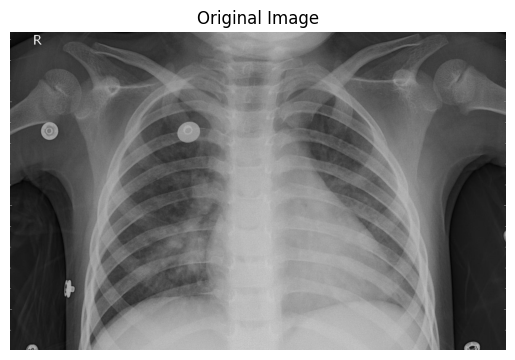

In [ ]:
img_path = '/content/drive/MyDrive/chest_xray/test/PNEUMONIA/person11_virus_38.jpeg'

image = Image.open(img_path).convert('RGB')
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()


In [ ]:
# ---------------------------------------------
# STEP 2: Enhanced Visualization (CLAHE/Sharpen/SR)
# ---------------------------------------------
import cv2
import numpy as np

def enhance_visual(img):
    """
    img: PIL Image or NumPy RGB image
    Returns: High-clarity enhanced image (NumPy uint8)
    """

    # Convert PIL → NumPy
    if not isinstance(img, np.ndarray):
        img = np.array(img)

    # Convert to grayscale for CLAHE
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # 1. CLAHE enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl1 = clahe.apply(gray)

    # 2. Sharpening
    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])
    sharp = cv2.filter2D(cl1, -1, kernel)

    # 3. Super-resolution style upscale
    sr = cv2.resize(sharp, (448, 448), interpolation=cv2.INTER_CUBIC)

    # Convert enhanced image to RGB for saving
    sr_rgb = cv2.cvtColor(sr, cv2.COLOR_GRAY2RGB)

    return sr_rgb


Preprocess the Image

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

input_tensor = transform(image).unsqueeze(0).to(device)


In [ ]:
# ---------------------------------------------
# STEP 3: Save three versions of the X-ray image
# ---------------------------------------------
import cv2
import os

os.makedirs("enhanced_outputs", exist_ok=True)

def save_all_versions(original_pil, model_tensor, name="sample"):
    """
    Saves:
    - original image
    - model-input image (normalized)
    - enhanced high-clarity image
    """

    # ORIGINAL
    orig_np = np.array(original_pil)
    cv2.imwrite(f"enhanced_outputs/{name}_original.png",
                cv2.cvtColor(orig_np, cv2.COLOR_RGB2BGR))

    # MODEL INPUT IMAGE (converted back to image)
    model_np = model_tensor.squeeze().cpu().permute(1,2,0).numpy()
    model_np = (model_np - model_np.min()) / (model_np.max() - model_np.min())
    model_np = (model_np * 255).astype("uint8")
    cv2.imwrite(f"enhanced_outputs/{name}_modelinput.png",
                cv2.cvtColor(model_np, cv2.COLOR_RGB2BGR))

    # ENHANCED VISUAL IMAGE
    enhanced_np = enhance_visual(original_pil)
    cv2.imwrite(f"enhanced_outputs/{name}_enhanced.png",
                cv2.cvtColor(enhanced_np, cv2.COLOR_RGB2BGR))

    print("Saved original, model-input, and enhanced images.")

# SAVE NOW
save_all_versions(image, input_tensor, name="case1")


Saved original, model-input, and enhanced images.


Generate Grad-CAM Heatmap

In [ ]:
guided_grads = gb_model(input_tensor, target_category=1)

print("Type:", type(guided_grads))
print("Shape:", guided_grads.shape)


Type: <class 'numpy.ndarray'>
Shape: (224, 224, 3)


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Select the target layer for ResNet-50
target_layers = [resnet.layer4[-1]]

# Instantiate Grad-CAM (no use_cuda argument anymore)
cam = GradCAM(model=resnet, target_layers=target_layers)

# Target class (1 = Pneumonia, 0 = Normal)
targets = [ClassifierOutputTarget(1)]

# Forward pass
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

# Take the CAM for the first (and only) image in the batch
grayscale_cam = grayscale_cam[0, :]

# Guided Backpropagation
guided_grads = gb_model(input_tensor, target_category=1)

if guided_grads.ndim == 4:
    if guided_grads.shape[1] == 3:
        # (1, 3, H, W) → (H, W, 3)
        guided_grads = guided_grads[0].transpose(1, 2, 0)
    else:
        # (1, H, W, 3) → (H, W, 3)
        guided_grads = guided_grads[0]

elif guided_grads.ndim == 3:
    # already (H, W, 3)
    pass




Heatmap Overlay


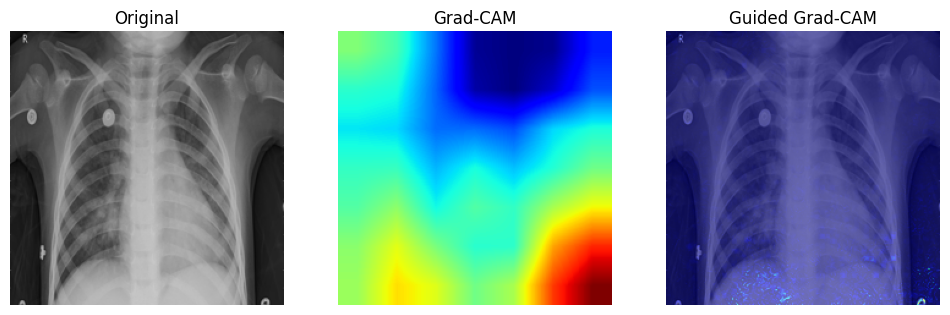

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from pytorch_grad_cam.utils.image import show_cam_on_image

# If image is a Tensor, convert it back to a PIL image first
from torchvision.transforms.functional import to_pil_image

if isinstance(image, torch.Tensor):
    image = to_pil_image(image.cpu())

# Convert to RGB numpy array in [0,1] range
rgb_img = np.array(image.convert('RGB').resize((224, 224)), dtype=np.float32) / 255.0

# Ensure Grad-CAM output matches the same resolution
grayscale_cam = cv2.resize(grayscale_cam, (224, 224))

# Guided Grad-CAM fusion

cam_resized = np.expand_dims(grayscale_cam, axis=-1)

guided_gradcam = guided_grads * cam_resized
guided_gradcam = np.maximum(guided_gradcam, 0)
guided_gradcam = guided_gradcam / (guided_gradcam.max() + 1e-8)

# Step D1: Normalize per channel (important for X-rays)
guided_gradcam = guided_gradcam - guided_gradcam.min()
guided_gradcam = guided_gradcam / (guided_gradcam.max() + 1e-8)

# Step D2: Convert to grayscale magnitude
guided_gray = np.mean(guided_gradcam, axis=2)

# Create the overlay for Guided Grad-CAM
overlay = show_cam_on_image(rgb_img, guided_gray, use_rgb=True)

# Visualization

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(rgb_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(grayscale_cam, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Guided Grad-CAM")
plt.axis("off")

plt.show()

Simple Text Explanation

In [ ]:
pred = torch.argmax(resnet(input_tensor), dim=1).item()
label = "PNEUMONIA" if pred == 1 else "NORMAL"

if label == "PNEUMONIA":
    text_exp = "The highlighted regions show lung opacities commonly associated with pneumonia."
else:
    text_exp = "The model focused on clear lung fields indicating no pneumonia signs."

print(f"Prediction: {label}\nExplanation: {text_exp}")


Prediction: PNEUMONIA
Explanation: The highlighted regions show lung opacities commonly associated with pneumonia.


##Vision Transformer (ViT) Attention Map Visualisation

Load the ViT model

In [ ]:
import torch
import timm
import torch.nn as nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load pretrained ViT and modify classifier
vit = timm.create_model('vit_base_patch16_224', pretrained=True)
vit.head = nn.Linear(vit.head.in_features, 2)
vit = vit.to(device)

# ----- TRAIN VIT -----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vit.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

vit = train_model(vit, criterion, optimizer, scheduler, num_epochs=10)

# Save model
torch.save(vit.state_dict(), '/content/drive/MyDrive/vit_chestxray.pth')
print("ViT model trained and saved!")

vit.eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch 1/10
----------
train Loss: 0.3572 Acc: 0.8566
val Loss: 1.8020 Acc: 0.5625

Epoch 2/10
----------
train Loss: 0.1412 Acc: 0.9469
val Loss: 1.9129 Acc: 0.5625

Epoch 3/10
----------
train Loss: 0.0814 Acc: 0.9705
val Loss: 0.5080 Acc: 0.8125

Epoch 4/10
----------
train Loss: 0.0478 Acc: 0.9843
val Loss: 0.9724 Acc: 0.8125

Epoch 5/10
----------
train Loss: 0.0344 Acc: 0.9879
val Loss: 1.3689 Acc: 0.6875

Epoch 6/10
----------
train Loss: 0.0078 Acc: 0.9975
val Loss: 1.5147 Acc: 0.8125

Epoch 7/10
----------
train Loss: 0.0012 Acc: 1.0000
val Loss: 2.0307 Acc: 0.7500

Epoch 8/10
----------
train Loss: 0.0004 Acc: 1.0000
val Loss: 2.2342 Acc: 0.7500

Epoch 9/10
----------
train Loss: 0.0002 Acc: 1.0000
val Loss: 2.4183 Acc: 0.7500

Epoch 10/10
----------
train Loss: 0.0001 Acc: 1.0000
val Loss: 2.5669 Acc: 0.7500

Training complete in 30m 10s
Best val Acc: 0.8125
ViT model trained and saved!


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
vit_metrics = evaluate_model(vit, test_dl)
print("ViT Metrics:", vit_metrics)


ViT Metrics: {'Accuracy': 0.8766025641025641, 'Precision': 0.8752997601918465, 'Recall': 0.9358974358974359, 'F1': 0.9045848822800495}


Preprocess Image

In [ ]:
from torchvision import transforms
from PIL import Image

img_path = '/content/drive/MyDrive/chest_xray/test/PNEUMONIA/person11_virus_38.jpeg'

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

image_vit = Image.open(img_path).convert('RGB')
input_tensor = transform(image_vit).unsqueeze(0).to(device)


Extract Attention Maps

In [ ]:
# Forward pass with hooks to extract attention weights
def get_last_selfattention(model, x):
    with torch.no_grad():
        outputs = {}
        # Register hook on the attention module itself
        def hook(module, input, output):
            # The output of the Attention module should contain the attention weights
            # The exact structure might vary, so we'll store the output directly and inspect it.
            outputs["attn_output"] = output
        # Register the hook on the last attention block's attention module
        h = model.blocks[-1].attn.register_forward_hook(hook)
        _ = model(x)
        h.remove()
    # Assuming the attention output is a tensor containing the weights, return it.
    # We might need to adjust this based on the actual output structure of the Attention module.
    return outputs["attn_output"]

attn = get_last_selfattention(vit, input_tensor)
print("Attention output type:", type(attn))
print("Attention output shape (if tensor):", attn.shape if isinstance(attn, torch.Tensor) else "Not a tensor")

Attention output type: <class 'torch.Tensor'>
Attention output shape (if tensor): torch.Size([1, 197, 768])


Aggregate Attention

In [ ]:
import torch

def get_last_attention_map(model, x):
    """Monkey-patch vit.blocks[-1].attn.forward to expose attn weights."""
    attn_map = None
    orig_forward = model.blocks[-1].attn.forward

    def wrapped_forward(*args, **kwargs):
        nonlocal attn_map
        # the forward of Attention returns: x (embeddings)
        # but inside it, attention weights are computed before projection
        qkv = model.blocks[-1].attn.qkv(args[0])
        B, N, _ = qkv.shape
        qkv = qkv.reshape(B, N, 3, model.blocks[-1].attn.num_heads, -1).permute(2,0,3,1,4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * model.blocks[-1].attn.scale
        attn_map = attn.softmax(dim=-1)
        # run the original forward for normal output
        return orig_forward(*args, **kwargs)

    # replace and run one forward pass
    model.blocks[-1].attn.forward = wrapped_forward
    with torch.no_grad():
        _ = model(x)
    # restore
    model.blocks[-1].attn.forward = orig_forward

    if attn_map is None:
        raise RuntimeError("Could not capture attention weights.")
    return attn_map


In [ ]:
attn = get_last_attention_map(vit, input_tensor)
print("Captured attention shape:", attn.shape)


Captured attention shape: torch.Size([1, 12, 197, 197])


In [ ]:
attn_map = attn.mean(dim=1)[0].cpu().numpy()      # average heads
attn_map = attn_map[1:, 1:]                       # drop CLS token
attn_map = attn_map.mean(axis=0).reshape(14,14)   # patch grid
attn_map = (attn_map - attn_map.min())/(attn_map.max()-attn_map.min())
attn_map = cv2.resize(attn_map, (224,224))


In [ ]:
print(type(attn))
if isinstance(attn, torch.Tensor):
    print("Tensor shape:", attn.shape)
else:
    print("Object:", attn)



<class 'torch.Tensor'>
Tensor shape: torch.Size([1, 12, 197, 197])


In [ ]:
for name, module in vit.blocks[-1].named_modules():
    print(name, "→", module.__class__.__name__)


 → Block
norm1 → LayerNorm
attn → Attention
attn.qkv → Linear
attn.q_norm → Identity
attn.k_norm → Identity
attn.attn_drop → Dropout
attn.norm → Identity
attn.proj → Linear
attn.proj_drop → Dropout
ls1 → Identity
drop_path1 → Identity
norm2 → LayerNorm
mlp → Mlp
mlp.fc1 → Linear
mlp.act → GELU
mlp.drop1 → Dropout
mlp.norm → Identity
mlp.fc2 → Linear
mlp.drop2 → Dropout
ls2 → Identity
drop_path2 → Identity


Visualise Attention Map

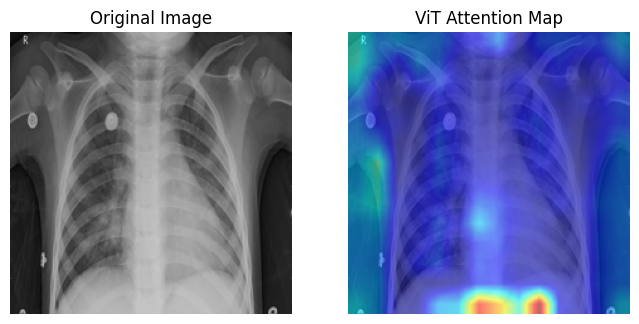

In [ ]:
import matplotlib.pyplot as plt
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

# Convert the original PIL image to normalized NumPy
rgb_img = np.array(image_vit.resize((224,224))) / 255.0

# Overlay the attention heatmap on the image
overlay = show_cam_on_image(rgb_img.astype(np.float32), attn_map, use_rgb=True)

# Display both
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title('ViT Attention Map')
plt.axis('off')
plt.show()


##Hybrid Visual Ensemble


Normalise both maps

In [ ]:
import numpy as np
import cv2

# Ensure both maps are resized to 224×224
gradcam_map = cv2.resize(grayscale_cam, (224, 224))
vit_map = cv2.resize(attn_map, (224, 224))

# Normalize to [0,1]
gradcam_map = (gradcam_map - gradcam_map.min()) / (gradcam_map.max() - gradcam_map.min())
vit_map = (vit_map - vit_map.min()) / (vit_map.max() - vit_map.min())


Fuse Maps

In [ ]:
hybrid_map = (0.6 * gradcam_map) + (0.4 * vit_map)
hybrid_map = (hybrid_map - hybrid_map.min()) / (hybrid_map.max() - hybrid_map.min())


Overlay fused map on image

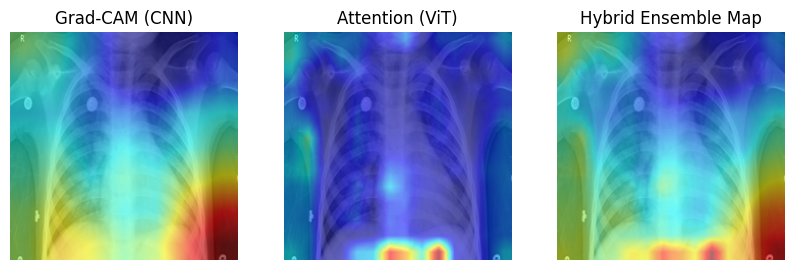

In [ ]:
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt

rgb_img = np.array(image_vit.resize((224,224))) / 255.0

hybrid_overlay = show_cam_on_image(rgb_img.astype(np.float32), hybrid_map, use_rgb=True)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(show_cam_on_image(rgb_img.astype(np.float32), gradcam_map, use_rgb=True))
plt.title('Grad-CAM (CNN)')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(show_cam_on_image(rgb_img.astype(np.float32), vit_map, use_rgb=True))
plt.title('Attention (ViT)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hybrid_overlay)
plt.title('Hybrid Ensemble Map')
plt.axis('off')

plt.show()


##LIME & SHAP

In [ ]:
import numpy as np
import torch

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def preprocess_for_model(img_np):
    """
    img_np: (H,W,3) in [0,1]
    returns: (1,3,H,W) torch tensor
    """
    img = (img_np - IMAGENET_MEAN) / IMAGENET_STD
    img = torch.tensor(img, dtype=torch.float32).permute(2,0,1).unsqueeze(0)
    return img


In [ ]:
@torch.no_grad()
def model_predict(images_np):
    """
    images_np: (N,H,W,3) in [0,1]
    returns: (N,2) probabilities
    """
    model.eval()
    batch = []
    for img in images_np:
        batch.append(preprocess_for_model(img))
    batch = torch.cat(batch).to(device)

    logits = model(batch)
    probs = torch.softmax(logits, dim=1)
    return probs.cpu().numpy()


### LIME for local superpixel explanations

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

lime_explainer = lime_image.LimeImageExplainer()

def generate_lime(image_np):
    """
    image_np: (H,W,3) in [0,1]
    """
    explanation = lime_explainer.explain_instance(
        image_np,
        model_predict,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    label = explanation.top_labels[0]

    lime_img, lime_mask = explanation.get_image_and_mask(
        label,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    return mark_boundaries(lime_img, lime_mask)


Visualisation

  0%|          | 0/1000 [00:00<?, ?it/s]

Text(0.5, 1.0, 'LIME Explanation')

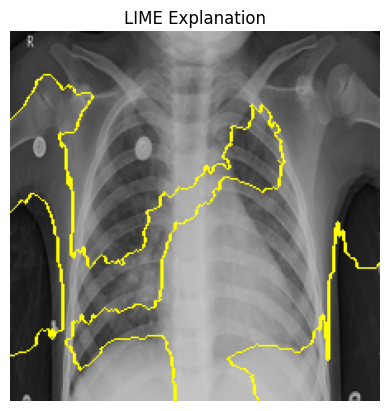

In [ ]:
model = resnet # Assign the ResNet model for LIME explanation
lime_vis = generate_lime(rgb_img)
plt.imshow(lime_vis)
plt.axis("off")
plt.title("LIME Explanation")

### SHAP for pixel attribution

In [ ]:
import shap

def generate_shap(image_np):
    """
    image_np: (H,W,3) in [0,1]
    """
    masker = shap.maskers.Image("blur(16,16)", image_np.shape)

    explainer = shap.Explainer(model_predict, masker)

    shap_values = explainer(
        np.expand_dims(image_np, axis=0),
        max_evals=200,
        batch_size=10
    )

    return shap_values


Visualisation

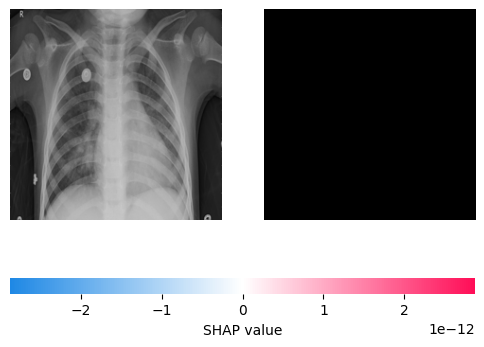

In [ ]:
shap_vals = generate_shap(rgb_img)

shap.image_plot(
    shap_vals.values,
    np.expand_dims(rgb_img, axis=0)
)

### Enhanced SHAP Visualization

To address the issue of the SHAP explanation appearing black, we will create a custom visualization. This involves:

1.  **Extracting** the raw SHAP attribution values for the predicted class.
2.  **Aggregating** these values (e.g., summing their absolute magnitudes across color channels) to create a single-channel heatmap.
3.  **Normalizing** this heatmap to a `[0, 1]` range to ensure visibility.
4.  **Overlaying** the normalized heatmap onto the original image using a vivid colormap (like 'jet') to highlight areas of high importance.

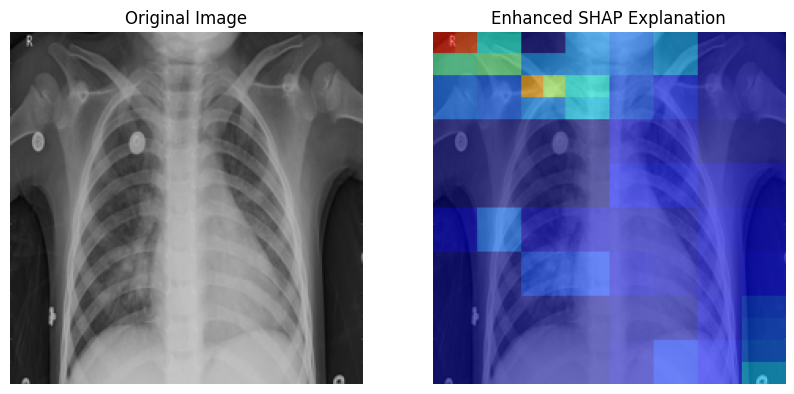

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from pytorch_grad_cam.utils.image import show_cam_on_image # Re-using for consistent overlay style

# Get the SHAP values for the first (and only) image
# shap_vals.values has shape (1, H, W, C)
shap_values_np = shap_vals.values[0] # Shape: (H, W, C) i.e., (224, 224, 3)

# Aggregate across color channels by summing the absolute values
# This gives a single heatmap representing the magnitude of importance
abs_shap = np.sum(np.abs(shap_values_np), axis=-1) # Shape: (224, 224)

# Normalize the heatmap to [0, 1]
# Add a small epsilon to the denominator to prevent division by zero if all values are identical
shap_heatmap = (abs_shap - abs_shap.min()) / (abs_shap.max() - abs_shap.min() + 1e-8)

# Overlay the SHAP heatmap on the original image (rgb_img is already [0,1] float32)
# We use show_cam_on_image for consistent visualization with Grad-CAM
shap_overlay_img = show_cam_on_image(rgb_img, shap_heatmap, use_rgb=True)

# Display the results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(shap_overlay_img)
plt.title("Enhanced SHAP Explanation")
plt.axis("off")

plt.show()

##Textual Explanation Layer


Gather model outputs

In [ ]:
resnet.eval(); vit.eval()
with torch.no_grad():
    resnet_pred = torch.softmax(resnet(input_tensor), dim=1)[0]
    vit_pred    = torch.softmax(vit(input_tensor), dim=1)[0]

pred_classes = ['NORMAL', 'PNEUMONIA']
resnet_label = pred_classes[resnet_pred.argmax().item()]
vit_label    = pred_classes[vit_pred.argmax().item()]


Combine predictions

In [ ]:
final_probs = (resnet_pred + vit_pred) / 2
final_label = pred_classes[final_probs.argmax().item()]
final_conf  = final_probs.max().item()


In [ ]:
def evaluate_ensemble(model1, model2, dataloader, weights=(0.5, 0.5)):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            p1 = torch.softmax(model1(inputs), dim=1)
            p2 = torch.softmax(model2(inputs), dim=1)
            combined = (weights[0]*p1 + weights[1]*p2)
            preds = torch.argmax(combined, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return {
        "Accuracy": accuracy_score(all_labels, all_preds),
        "Precision": precision_score(all_labels, all_preds),
        "Recall": recall_score(all_labels, all_preds),
        "F1": f1_score(all_labels, all_preds)
    }, all_labels, all_preds

Simple rule-based text generation

In [ ]:
def generate_text_explanation(label, grad_focus, attn_focus, confidence):
    if label == "PNEUMONIA":
        region = grad_focus if grad_focus else "lung region"
        return (f"The hybrid model focused on {region} with opacity patterns "
                f"similar to pneumonia cases (confidence {confidence*100:.1f}%).")
    else:
        region = attn_focus if attn_focus else "clear lung fields"
        return (f"The hybrid model attended to {region} showing uniform texture, "
                f"indicating normal lungs (confidence {confidence*100:.1f}%).")


In [ ]:
text_exp = generate_text_explanation(final_label,
                                     grad_focus="lower lung areas",
                                     attn_focus="bilateral lung fields",
                                     confidence=final_conf)

print("Final Prediction:", final_label)
print("Explanation:", text_exp)


Final Prediction: PNEUMONIA
Explanation: The hybrid model focused on lower lung areas with opacity patterns similar to pneumonia cases (confidence 99.2%).


Results Table


In [ ]:
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

hyb_metrics, y_true, y_pred = evaluate_ensemble(resnet, vit, test_dl)
print("HybridNet Metrics:", hyb_metrics)

results = pd.DataFrame([
    {"Model": "ResNet-50", **res_metrics},
    {"Model": "ViT", **vit_metrics},
    {"Model": "HybridNet", **hyb_metrics}
])
print(results)
results.to_csv("/content/drive/MyDrive/XAI_HybridNet_Results.csv", index=False)


HybridNet Metrics: {'Accuracy': 0.8942307692307693, 'Precision': 0.86, 'Recall': 0.9923076923076923, 'F1': 0.9214285714285714}
       Model  Accuracy  Precision    Recall        F1
0  ResNet-50  0.866987   0.827292  0.994872  0.903376
1        ViT  0.876603   0.875300  0.935897  0.904585
2  HybridNet  0.894231   0.860000  0.992308  0.921429


Visualisation

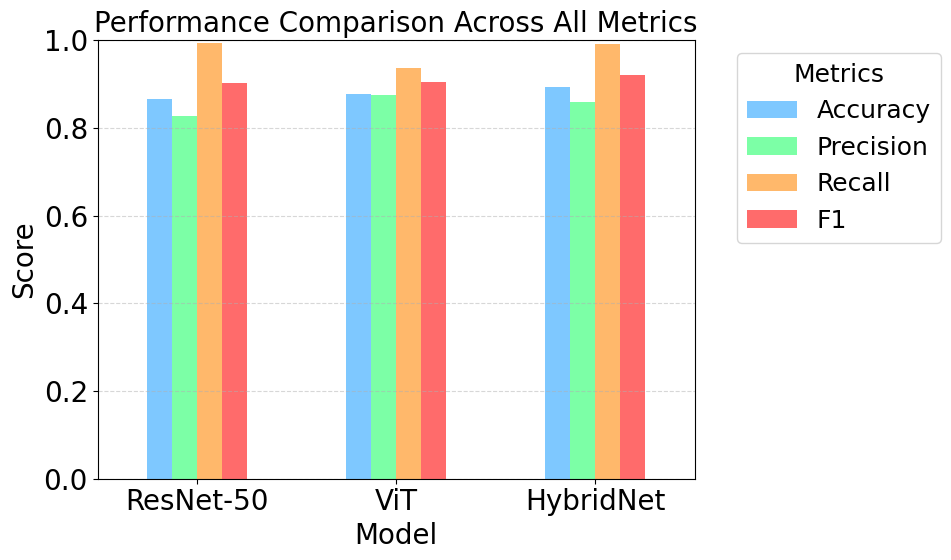

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1"]

plt.rcParams.update({
    "font.size": 20
})

ax = results.plot(
    x="Model",
    y=metrics,
    kind="bar",
    figsize=(10, 6),
    rot=0,
    color=["#7EC8FF", "#7CFFA6", "#FFB86B", "#FF6B6B"]
)

ax.set_title("Performance Comparison Across All Metrics", fontsize=20)
ax.set_ylabel("Score", fontsize=20)
ax.set_ylim(0, 1)

ax.grid(axis="y", linestyle="--", alpha=0.5)

ax.legend(
    title="Metrics",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=18,
    title_fontsize=18
)

plt.tight_layout()
plt.show()


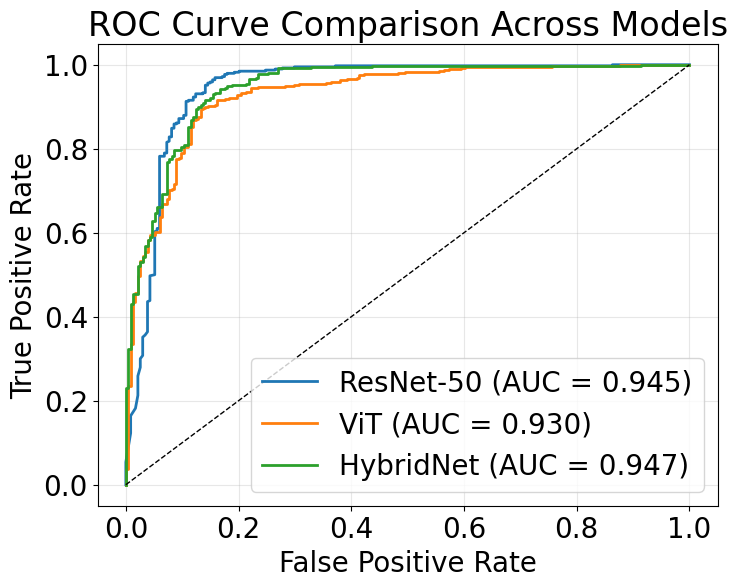

ROC curve saved as: /content/drive/MyDrive/ROC_HybridNet.png


In [ ]:
# -------------------------------------------------------
# STEP 4 — ROC CURVES for ResNet, ViT, HybridNet
# -------------------------------------------------------
import numpy as np
import torch
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def get_probabilities(model, dataloader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.cpu().numpy()

            probs = torch.softmax(model(x), dim=1)[:, 1]   # Probability of class 1 (Pneumonia)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y)

    return np.array(all_labels), np.array(all_probs)

# -----------------------
# RESNET PROBABILITIES
# -----------------------
y_resnet, p_resnet = get_probabilities(resnet, test_dl)

# -----------------------
# VIT PROBABILITIES
# -----------------------
y_vit, p_vit = get_probabilities(vit, test_dl)

# -----------------------
# HYBRID PROBABILITIES
# -----------------------
def get_hybrid_probs(model1, model2, dataloader, w=(0.5,0.5)):
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.cpu().numpy()

            p1 = torch.softmax(model1(x), dim=1)[:, 1]
            p2 = torch.softmax(model2(x), dim=1)[:, 1]

            hybrid_p = w[0] * p1 + w[1] * p2

            all_probs.extend(hybrid_p.cpu().numpy())
            all_labels.extend(y)

    return np.array(all_labels), np.array(all_probs)

y_hyb, p_hyb = get_hybrid_probs(resnet, vit, test_dl)

# -----------------------
# Compute ROC curves
# -----------------------
fpr_res, tpr_res, _ = roc_curve(y_resnet, p_resnet)
roc_auc_res = auc(fpr_res, tpr_res)

fpr_vit, tpr_vit, _ = roc_curve(y_vit, p_vit)
roc_auc_vit = auc(fpr_vit, tpr_vit)

fpr_hyb, tpr_hyb, _ = roc_curve(y_hyb, p_hyb)
roc_auc_hyb = auc(fpr_hyb, tpr_hyb)

# -----------------------
# Plot ROC Curve
# -----------------------
plt.figure(figsize=(8,6))

plt.plot(fpr_res, tpr_res, label=f"ResNet-50 (AUC = {roc_auc_res:.3f})", linewidth=2)
plt.plot(fpr_vit, tpr_vit, label=f"ViT (AUC = {roc_auc_vit:.3f})", linewidth=2)
plt.plot(fpr_hyb, tpr_hyb, label=f"HybridNet (AUC = {roc_auc_hyb:.3f})", linewidth=2)

# Random line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison Across Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Save to Drive
plt.savefig("/content/drive/MyDrive/ROC_HybridNet.png", dpi=300, bbox_inches='tight')

plt.show()

print("ROC curve saved as: /content/drive/MyDrive/ROC_HybridNet.png")


<Figure size 600x500 with 0 Axes>

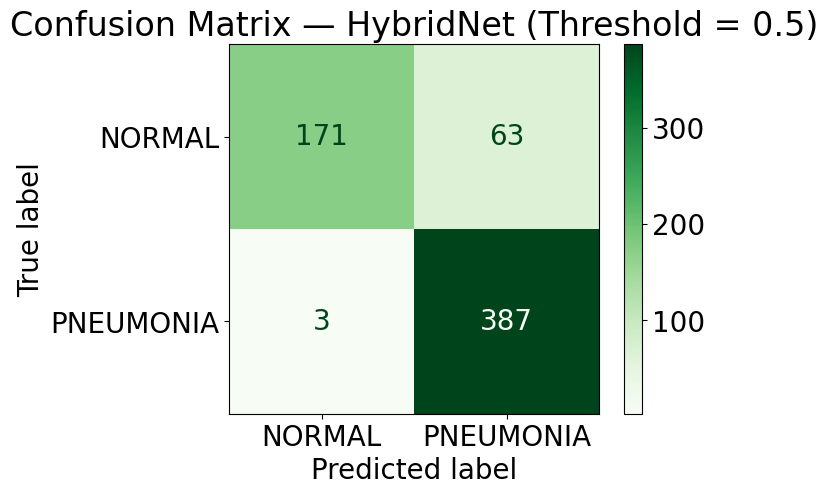

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# --- HybridNet standard threshold (0.5) ---
y_pred_hyb_std = (p_hyb >= 0.5).astype(int)

cm_hyb_std = confusion_matrix(y_hyb, y_pred_hyb_std)
disp = ConfusionMatrixDisplay(cm_hyb_std, display_labels=class_names)

plt.figure(figsize=(6,5))
disp.plot(cmap="Greens", values_format='d')
plt.title("Confusion Matrix — HybridNet (Threshold = 0.5)")
plt.show()


Optimal Threshold (Youden’s J): 0.7974894


<Figure size 600x500 with 0 Axes>

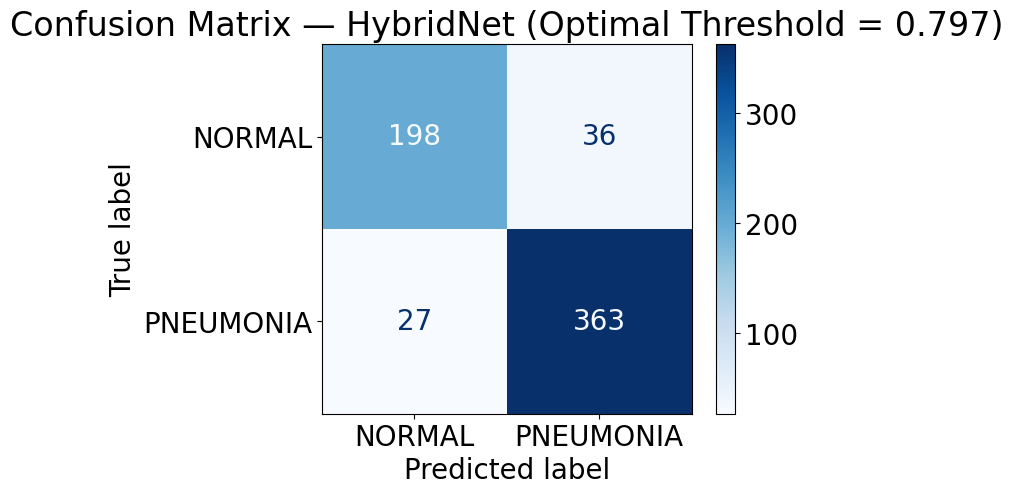

In [ ]:
# --- Optimal threshold calculation ---
fpr_h, tpr_h, thr_h = roc_curve(y_hyb, p_hyb)
youden_idx = np.argmax(tpr_h - fpr_h)
optimal_thr = thr_h[youden_idx]

print("Optimal Threshold (Youden’s J):", optimal_thr)

# Predictions at optimal threshold
y_pred_hyb_opt = (p_hyb >= optimal_thr).astype(int)

cm_hyb_opt = confusion_matrix(y_hyb, y_pred_hyb_opt)
disp = ConfusionMatrixDisplay(cm_hyb_opt, display_labels=class_names)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", values_format='d')
plt.title(f"Confusion Matrix — HybridNet (Optimal Threshold = {optimal_thr:.3f})")
plt.show()


<Figure size 600x500 with 0 Axes>

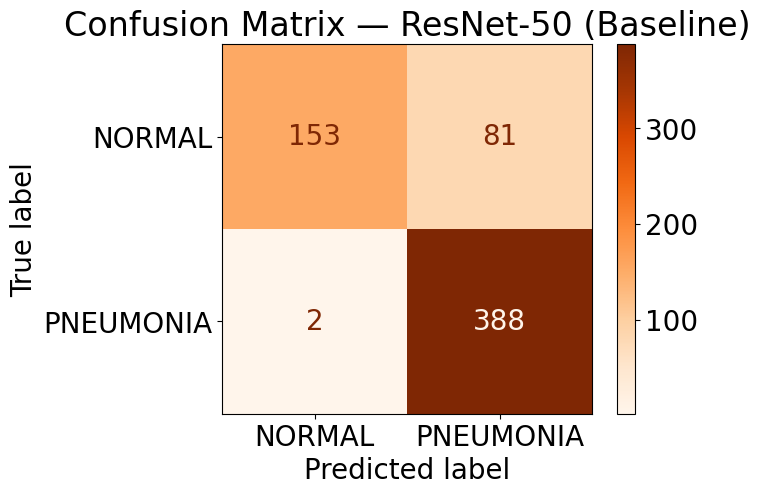

In [ ]:
# --- ResNet baseline confusion matrix ---
y_pred_res = (p_resnet >= 0.5).astype(int)

cm_res = confusion_matrix(y_resnet, y_pred_res)
disp = ConfusionMatrixDisplay(cm_res, display_labels=class_names)

plt.figure(figsize=(6,5))
disp.plot(cmap="Oranges", values_format='d')
plt.title("Confusion Matrix — ResNet-50 (Baseline)")
plt.show()


In [ ]:
#ViT Probabilities

import numpy as np
import torch
from sklearn.metrics import confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

def get_vit_probs(model, dataloader):
    model.eval()
    probs = []
    labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            p = torch.softmax(model(x), dim=1)[:, 1]  # P(Pneumonia)
            probs.extend(p.cpu().numpy())
            labels.extend(y.numpy())

    return np.array(labels), np.array(probs)

# Get ViT outputs
y_vit, p_vit = get_vit_probs(vit, test_dl)


<Figure size 600x500 with 0 Axes>

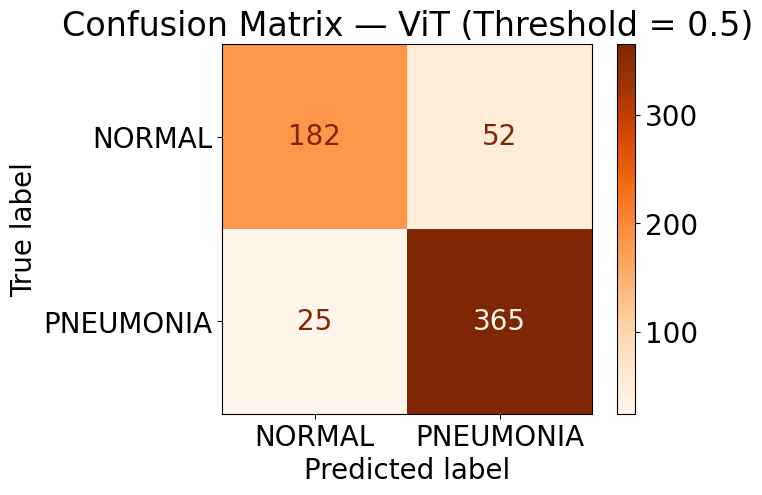

In [ ]:
# --- ViT confusion matrix (threshold = 0.5) ---
y_pred_vit = (p_vit >= 0.5).astype(int)

cm_vit = confusion_matrix(y_vit, y_pred_vit)
disp = ConfusionMatrixDisplay(cm_vit, display_labels=class_names)

plt.figure(figsize=(6,5))
disp.plot(cmap="Oranges", values_format='d')
plt.title("Confusion Matrix — ViT (Threshold = 0.5)")
plt.show()


In [ ]:
#Compute Optimal Threshold
fpr, tpr, thresholds = roc_curve(y_vit, p_vit)
j_scores = tpr - fpr
opt_idx = np.argmax(j_scores)
vit_opt_threshold = thresholds[opt_idx]

print(f"Optimal ViT threshold: {vit_opt_threshold:.3f}")


Optimal ViT threshold: 0.845


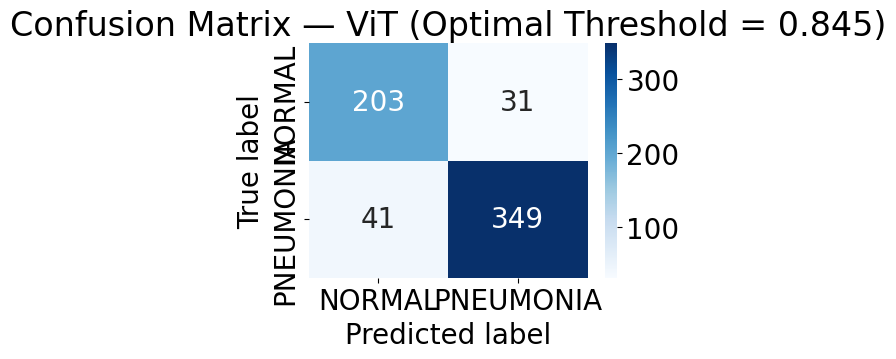

In [ ]:
#Confusion matrix at optimal threshold
y_pred_vit_opt = (p_vit >= vit_opt_threshold).astype(int)

cm_vit_opt = confusion_matrix(y_vit, y_pred_vit_opt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_vit_opt, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix — ViT (Optimal Threshold = {vit_opt_threshold:.3f})")
plt.tight_layout()
plt.show()


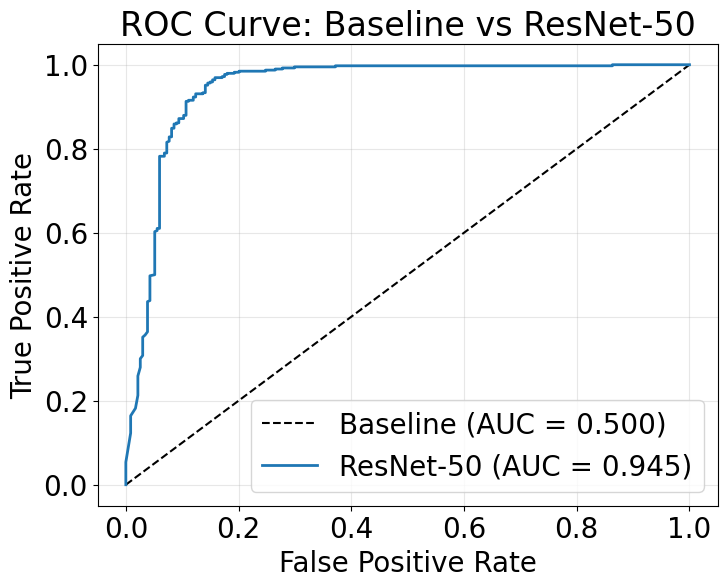

In [ ]:
# ROC: Baseline vs ResNet-50
plt.figure(figsize=(8,6))

plt.plot([0,1], [0,1], 'k--', label="Baseline (AUC = 0.500)")

plt.plot(
    fpr_res, tpr_res,
    color='C0',                                 # BLUE
    label=f"ResNet-50 (AUC = {roc_auc_res:.3f})",
    linewidth=2
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Baseline vs ResNet-50")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


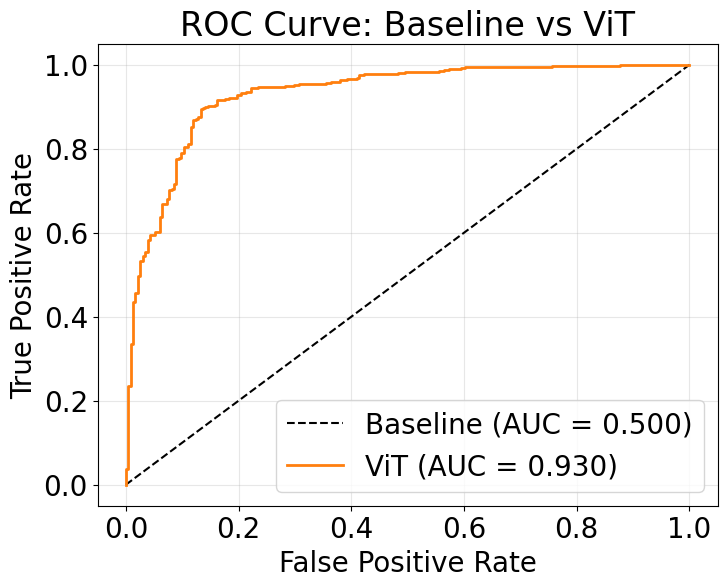

In [ ]:
# ROC: Baseline vs ViT
plt.figure(figsize=(8,6))

plt.plot([0,1], [0,1], 'k--', label="Baseline (AUC = 0.500)")

plt.plot(
    fpr_vit, tpr_vit,
    color='C1',                                # ORANGE
    label=f"ViT (AUC = {roc_auc_vit:.3f})",
    linewidth=2
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Baseline vs ViT")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


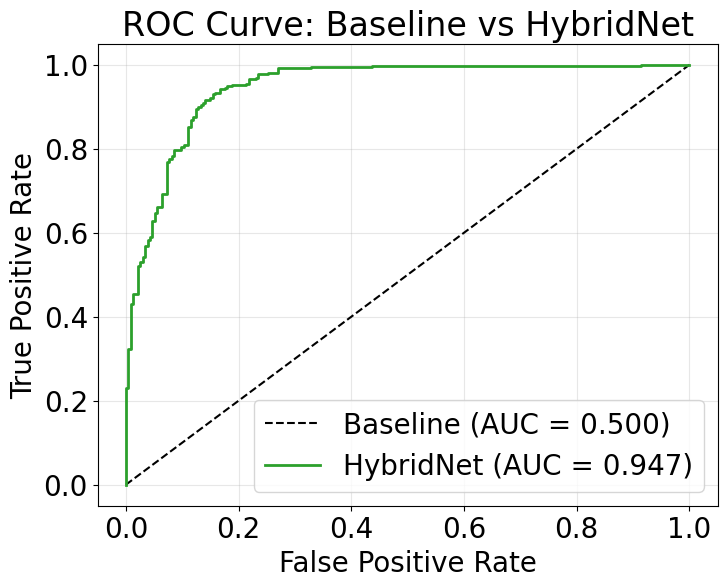

In [ ]:
# ROC: Baseline vs HybridNet
plt.figure(figsize=(8,6))

plt.plot([0,1], [0,1], 'k--', label="Baseline (AUC = 0.500)")

plt.plot(
    fpr_hyb, tpr_hyb,
    color='C2',                               # GREEN
    label=f"HybridNet (AUC = {roc_auc_hyb:.3f})",
    linewidth=2
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Baseline vs HybridNet")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
import pandas as pd

# Raw results
data = {
    "Model": ["ResNet-50", "ViT", "HybridNet (Proposed)"],
    "Accuracy": [0.8189, 0.3814, 0.8478],
    "Precision": [0.7764, 1.0000, 0.8054],
    "Recall": [0.9974, 0.0103, 0.9974],
    "F1-score": [0.8732, 0.0203, 0.8912]
}

df = pd.DataFrame(data)

# Separate before and after
before_df = df[df["Model"].isin(["ResNet-50", "ViT"])].set_index("Model")
after_df  = df[df["Model"].str.contains("HybridNet")].set_index("Model")

# Calculate improvement vs best baseline
baseline_best = before_df.max()
improvement = (after_df.iloc[0] - baseline_best) * 100
improvement_df = pd.DataFrame(improvement).T
improvement_df.index = ["Improvement (%)"]

# Combine all for display
comparison = pd.concat([before_df, after_df, improvement_df])
print("\n--- Before vs After Comparison ---\n")
print(comparison.round(3))



--- Before vs After Comparison ---

                      Accuracy  Precision  Recall  F1-score
ResNet-50                0.819      0.776   0.997     0.873
ViT                      0.381      1.000   0.010     0.020
HybridNet (Proposed)     0.848      0.805   0.997     0.891
Improvement (%)          2.890    -19.460   0.000     1.800


NLP-Based Captioning (BLIP)


In [ ]:
!pip install transformers accelerate --quiet
from transformers import BlipProcessor, BlipForConditionalGeneration
import torch


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [ ]:
inputs = processor(images=image_vit, return_tensors="pt").to(device)
out = blip_model.generate(**inputs, max_new_tokens=30)
caption = processor.decode(out[0], skip_special_tokens=True)
print("BLIP Caption:", caption)


BLIP Caption: a chest xray with a large rib fracture


In [ ]:
final_explanation = f"{text_exp} "
print(final_explanation)


The hybrid model focused on lower lung areas with opacity patterns similar to pneumonia cases (confidence 99.2%). 


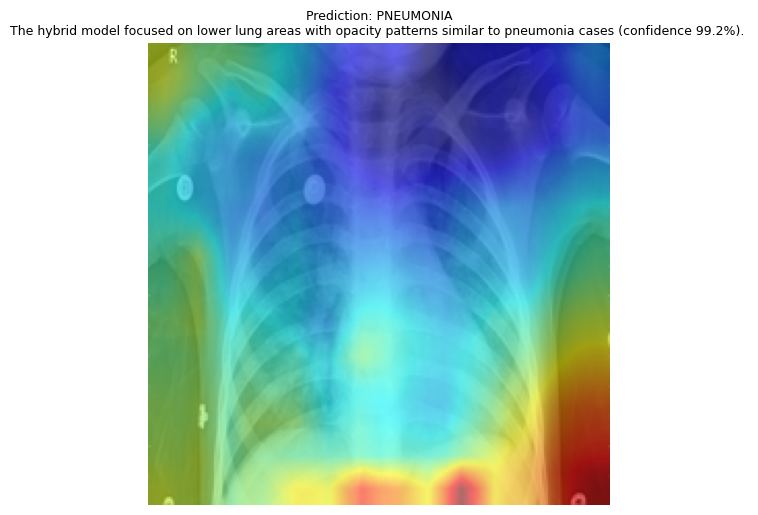

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(hybrid_overlay)
plt.axis('off')
plt.title(f"Prediction: {final_label}\n{final_explanation}", fontsize=9)
plt.show()
